#### Simple pipeline - Feature Scaling (Std_scaler), Estimator - Log Regression

In [132]:
from sklearn.pipeline import Pipeline

# feature scaling 
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn import set_config

In [133]:
# steps are declared on key value pairs

steps = [('standard_scaler',StandardScaler()),
         ('classifier', LogisticRegression())]

steps

[('standard_scaler', StandardScaler()), ('classifier', LogisticRegression())]

In [134]:
pipe = Pipeline(steps=steps)

# to visualize pipeline
set_config(display='diagram')
pipe

Pipeline(steps=[('standard_scaler', StandardScaler()),
                ('classifier', LogisticRegression())])

In [135]:
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=1000, n_features=21)

In [136]:
X.shape

(1000, 21)

In [137]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [138]:
pipe.fit(X_train, y_train)

Pipeline(steps=[('standard_scaler', StandardScaler()),
                ('classifier', LogisticRegression())])

In [139]:
y_pred = pipe.predict(X_test)

In [140]:
y_pred

array([0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1,
       0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1,
       0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1,
       1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1,
       1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1,

#### Intermediate Pipeline


In [141]:
from sklearn.decomposition import PCA
from sklearn.svm import SVC

In [142]:
steps = [('standard_scaler',StandardScaler()),
        ( 'PCA', PCA(n_components=3)),
        ('SVC', SVC())]

In [143]:
Intermediate_pipe = Pipeline(steps=steps)

In [144]:
Intermediate_pipe['standard_scaler'].fit_transform(X_train)

array([[ 0.4236926 ,  0.46028897, -0.45698389, ...,  0.84999589,
        -0.27185366, -0.628147  ],
       [-0.40985677, -1.49931947,  0.58559072, ..., -0.06173131,
         1.43335162, -0.62471175],
       [ 0.21235373, -0.85069988, -0.38129464, ..., -0.24565873,
         0.81079028, -0.37142981],
       ...,
       [-2.49603988,  2.01652042,  2.40327932, ..., -0.68645876,
        -0.8358156 , -0.62101485],
       [-0.56862031,  2.51886609,  0.7209736 , ..., -1.38322341,
        -0.31778962, -0.39011494],
       [-0.49601096,  0.67841532,  0.69198725, ...,  0.58038748,
         0.92807438,  0.76827634]])

In [145]:
Intermediate_pipe.fit(X_train, y_train)

Pipeline(steps=[('standard_scaler', StandardScaler()),
                ('PCA', PCA(n_components=3)), ('SVC', SVC())])

In [146]:
y_pred2 = Intermediate_pipe.predict(X_test)

#### Complex Pipeline -  By column wise pipeline

In [147]:
# missing values 
# numerical variables we can use simple imputer
from sklearn.impute import SimpleImputer
import numpy as np

# encoding categorical variables
from sklearn.preprocessing import  OneHotEncoder

# combining numerical and categorical processing pipelines
from sklearn.compose import ColumnTransformer

from sklearn.pipeline import make_pipeline

In [148]:
# Processing numerical variables with a pipeline
numeric_processor = Pipeline(
    steps= [('mean_imputer', SimpleImputer(missing_values=np.nan,strategy='mean')),
            ('scaler',StandardScaler())]
)

In [149]:
categorical_processor = Pipeline(
    steps=[('categorical_imputer',SimpleImputer(fill_value='missing',strategy='constant')),
           ('one_hot_encoder', OneHotEncoder(handle_unknown='ignore'))]
)

In [150]:
categorical_processor

Pipeline(steps=[('categorical_imputer',
                 SimpleImputer(fill_value='missing', strategy='constant')),
                ('one_hot_encoder', OneHotEncoder(handle_unknown='ignore'))])

In [151]:
preprocessor = ColumnTransformer(
[("categorical", categorical_processor, ["gender",'City']),
 ("numerical", numeric_processor, ['age', 'height'])]
)

In [152]:
preprocessor

ColumnTransformer(transformers=[('categorical',
                                 Pipeline(steps=[('categorical_imputer',
                                                  SimpleImputer(fill_value='missing',
                                                                strategy='constant')),
                                                 ('one_hot_encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['gender', 'City']),
                                ('numerical',
                                 Pipeline(steps=[('mean_imputer',
                                                  SimpleImputer()),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'height'])])

In [153]:
pipe = make_pipeline(preprocessor, LogisticRegression())
pipe

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('categorical',
                                                  Pipeline(steps=[('categorical_imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('one_hot_encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'City']),
                                                 ('numerical',
                                                  Pipeline(steps=[('mean_imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'height'])])),
                ('logisticregression', LogisticRegression())])

#### Complex Pipeline - Hyperparameter tuning

In [154]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

import seaborn as sns


In [155]:
df = sns.load_dataset('tips')

In [156]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [157]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [158]:
# data split on Dependent vs Independent variables
# X = df.drop('tip',axis=1)
X = df.iloc[:,1:]
y = df['total_bill']

In [159]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((195, 6), (49, 6))


Column: tip
Skewness: 1.456
High skewness detected. Consider:
- Log transformation if the values are all positive.
- Box-Cox transformation (if appropriate for your data).
Range of values seems appropriate.

Column: size
Skewness: 1.439
High skewness detected. Consider:
- Log transformation if the values are all positive.
- Box-Cox transformation (if appropriate for your data).
Range of values seems appropriate.


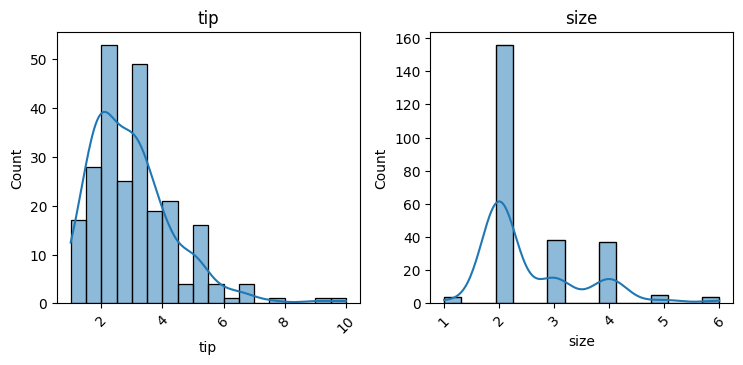

In [127]:
# import matplotlib.pyplot as plt
# from scipy.stats import boxcox, skew
# # Assuming your DataFrame is named life_expectancy_df
# # List of predictors (excluding the target and any categorical features)
# # Select only th#e numeric columns for correlation analysis
# numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

# predictors = [col for col in numeric_columns if col != 'total_bill']  

# # Function to assess a column and suggest preprocessing
# def assess_and_suggest(column):
#     data = df[column].dropna()

#     # Skewness
#     skewness = skew(data)
    
#     print(f"\nColumn: {column}")
#     print(f"Skewness: {skewness:.3f}")

#     if abs(skewness) > 1:  # Adjust this threshold if needed
#         print("High skewness detected. Consider:")
#         print("- Log transformation if the values are all positive.")
#         print("- Box-Cox transformation (if appropriate for your data).")
#     else:
#         print("Skewness within acceptable range.")

#     # Large range (optional, depending on your model)
#     if data.max() - data.min() > 1000:  # Adjust this threshold
#         print("Large range of values. Consider standardization or normalization:")
#         print("- Standardization (z-scores) if your model assumes normally distributed features.")
#         print("- Min-Max scaling (normalization) to scale values between 0 and 1.")
#     else:
#         print("Range of values seems appropriate.")

# # Analyze and suggest for each predictor
# for predictor in predictors:
#     assess_and_suggest(predictor)

# # Visualize the distributions
# plt.figure(figsize=(15, 10))
# for i, predictor in enumerate(predictors):
#     plt.subplot(3, 4, i+1)
#     sns.histplot(df[predictor], kde=True)
#     plt.title(predictor)
#     plt.xticks(rotation=45)  # Rotate x-axis labels to avoid overlap
#     plt.tight_layout()  # Ensure tight layout to minimize overlaps
# plt.show()


In [160]:
df.shape

(244, 7)

In [161]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [162]:
numeric_processor = Pipeline(
    steps=[('imputer', SimpleImputer(missing_values=np.nan, strategy='mean')),
           ('scaler',StandardScaler())]
)


categorical_processor = Pipeline(
    steps= [('constandt_imputer', SimpleImputer(fill_value='missing', strategy='constant')),
            ('one_hot_encoder',OneHotEncoder(handle_unknown= "ignore"))
            ]
)

preprocessor = ColumnTransformer(
    [
        ("categorical", categorical_processor, ['sex','smoker','day','time']),
        ("numerical", numeric_processor, ['tip','size'])
    ]
)

In [163]:
Pipe = Pipeline(
    steps=[('Preprocessor', preprocessor),
           ('Regressor', RandomForestRegressor())]
)

from sklearn import set_config
set_config(display="diagram")

Pipe

Pipeline(steps=[('Preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  Pipeline(steps=[('constandt_imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('one_hot_encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'smoker', 'day',
                                                   'time']),
                                                 ('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['tip', 'size'])])),
                ('Regressor', RandomForestRegressor())])

In [164]:
Pipe.fit(X_train, y_train)

Pipeline(steps=[('Preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  Pipeline(steps=[('constandt_imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('one_hot_encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'smoker', 'day',
                                                   'time']),
                                                 ('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['tip', 'size'])])),
                ('Regressor', RandomForestRegressor())])

In [165]:
Pipe.predict(X_test)

array([17.8027    , 13.59971333, 20.4389    , 29.036     , 12.81228667,
       13.94564833, 15.7133    , 15.42805833, 20.6712    , 20.42704   ,
       18.8892    , 13.83386667, 10.60401429, 13.94564833, 11.0543    ,
       13.48888   , 22.0554    , 18.9248    , 14.40231   , 27.4356    ,
       19.3735    , 20.2902    , 19.2646    , 13.83386667, 24.5773    ,
       15.758455  , 13.9448    , 24.8531    , 20.4389    , 24.3097    ,
       22.6261    , 13.3777    , 18.4119    , 19.3296    , 21.1922    ,
       21.06026667, 12.84691429, 29.4775    , 18.75216667, 14.16308333,
       13.0475    , 12.10235869, 15.93895571, 13.5212    , 14.41119571,
       11.1262    , 19.06426667, 17.4527    , 11.30386429])

In [166]:
import warnings

warnings.filterwarnings('ignore')

In [171]:
param_grid = {
    "Regressor__n_estimators": [10, 50, 100],
    "Regressor__max_features": ["auto","sqrt","log2"],
    "Regressor__max_depth": [4,5,6,7,8]
}

In [172]:
grid_search = GridSearchCV(Pipe, param_grid, n_jobs= -1 )

In [173]:
grid_search.fit(X_train, y_train)

GridSearchCV(estimator=Pipeline(steps=[('Preprocessor',
                                        ColumnTransformer(transformers=[('categorical',
                                                                         Pipeline(steps=[('constandt_imputer',
                                                                                          SimpleImputer(fill_value='missing',
                                                                                                        strategy='constant')),
                                                                                         ('one_hot_encoder',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['sex',
                                                                          'smoker',
                                                                          'day',
                                                                          'time']),
                                                                        ('numerical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['tip',
                                                                          'size'])])),
                                       ('Regressor', RandomForestRegressor())]),
             n_jobs=-1,
             param_grid={'Regressor__max_depth': [4, 5, 6, 7, 8],
                         'Regressor__max_features': ['auto', 'sqrt', 'log2'],
                         'Regressor__n_estimators': [10, 50, 100]})

In [174]:
grid_search.best_params_

{'Regressor__max_depth': 6,
 'Regressor__max_features': 'sqrt',
 'Regressor__n_estimators': 50}

In [175]:
Pipe = Pipeline(
    steps=[('Preprocessor', preprocessor),
           ('Regressor', RandomForestRegressor(max_depth=6, max_features='sqrt', n_estimators=50))]
)

from sklearn import set_config
set_config(display="diagram")

Pipe

Pipeline(steps=[('Preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  Pipeline(steps=[('constandt_imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('one_hot_encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'smoker', 'day',
                                                   'time']),
                                                 ('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['tip', 'size'])])),
                ('Regressor',
                 RandomForestRegressor(max_depth=6, max_features='sqrt',
                                       n_estimators=50))])

In [176]:
Pipe.fit(X_train,y_train)

Pipeline(steps=[('Preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  Pipeline(steps=[('constandt_imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('one_hot_encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'smoker', 'day',
                                                   'time']),
                                                 ('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['tip', 'size'])])),
                ('Regressor',
                 RandomForestRegressor(max_depth=6, max_features='sqrt',
                                       n_estimators=50))])

In [177]:
Pipe.predict(X_test)

array([17.41449021, 15.13084471, 21.85045103, 29.7791992 , 13.55720746,
       19.868544  , 16.34602622, 16.27620117, 18.96354884, 18.01966446,
       17.02235046, 14.80696474, 11.1806474 , 19.868544  , 11.76942264,
       15.5962623 , 19.70233432, 19.4419405 , 16.88084638, 28.59647619,
       22.68755891, 21.66960482, 20.8243044 , 14.92483141, 23.48875469,
       15.77060002, 14.55495571, 20.99378137, 21.85045103, 26.88319235,
       22.33806087, 15.74470916, 22.26045895, 21.37450307, 20.7908441 ,
       24.17312527, 15.88135944, 24.91754167, 17.59183468, 16.72327079,
       14.71968846, 12.14118413, 15.74102963, 17.68805225, 15.01196699,
       15.31218665, 17.5406816 , 19.23247005, 13.01237017])